In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer


# 1. Load the data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2. FEATURE ENGINEERING: Physics (Kinetic Energy Proxy)
# The data dictionary says AC_MASS is 1-5. We force it to be numeric just in case.
train_df['AC_MASS_NUM'] = pd.to_numeric(train_df['AC_MASS'], errors='coerce')
test_df['AC_MASS_NUM'] = pd.to_numeric(test_df['AC_MASS'], errors='coerce')

# Calculate the proxy for Kinetic Energy: Mass * (Speed squared)
# (If Speed or Mass is missing, this results in NaN, which our pipeline will impute later!)
train_df['KINETIC_ENERGY'] = train_df['AC_MASS_NUM'] * (train_df['SPEED'] ** 2)
test_df['KINETIC_ENERGY'] = test_df['AC_MASS_NUM'] * (test_df['SPEED'] ** 2)

# 3. Define the columns to drop
cols_to_drop = [
    'INDEX_NR', 'REG', 'FLT', 'BIRD_BAND_NUMBER', 'LUPDATE', 'TRANSFER', 
    'LOCATION', 'COMMENTS', 'INCIDENT_DATE', 'AIRPORT', 
    'AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'AIRCRAFT', 'AMA', 'AMO', 
    'EMA', 'EMO', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 
    'REMAINS_COLLECTED', 'REMAINS_SENT', 'SOURCE', 'PERSON',
    'AC_MASS_NUM' # Drop the temporary column we used for math
]

train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
test_df = test_df.drop(columns=cols_to_drop, errors='ignore')

# 4. Separate features and target
X_train = train_df.drop(columns=['INDICATED_DAMAGE'])
y_train = train_df['INDICATED_DAMAGE']
X_test = test_df.copy()

# Fill empty text with blank strings for the NLP
X_train['REMARKS'] = X_train['REMARKS'].fillna('')
X_test['REMARKS'] = X_test['REMARKS'].fillna('')

# 5. Group the features (Notice KINETIC_ENERGY is added to the num_features list)
num_features = ['SPEED', 'HEIGHT', 'DISTANCE', 'INCIDENT_MONTH', 'INCIDENT_YEAR', 'KINETIC_ENERGY']

cat_mode_features = [
    'SIZE', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'AC_CLASS', 
    'NUM_STRUCK', 'NUM_SEEN', 'SPECIES_ID', 'SPECIES', 
    'OPID', 'OPERATOR', 'STATE', 'FAAREGION', 'RUNWAY', 
    'ENROUTE_STATE', 'WARNED', 'OUT_OF_RANGE_SPECIES'
]

cat_unknown_features = ['PHASE_OF_FLIGHT', 'TIME_OF_DAY', 'SKY', 'PRECIPITATION']
text_feature = 'REMARKS'

# 6. Build the individual transformer pipelines
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_mode_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(max_categories=20, handle_unknown='infrequent_if_exist', sparse_output=False)) 
])

cat_unknown_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(max_categories=10, handle_unknown='infrequent_if_exist', sparse_output=False))
])

# FEATURE ENGINEERING: Advanced NLP
# We increased max_features to 400, and added ngram_range=(1, 2) to catch two-word combinations.
text_transformer = TfidfVectorizer(max_features=400, ngram_range=(1, 2), stop_words='english')

# 7. Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat_mode', cat_mode_transformer, cat_mode_features),
        ('cat_unk', cat_unknown_transformer, cat_unknown_features),
        ('text', text_transformer, text_feature)
    ],
    remainder='drop' 
)

# 8. Execute the preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original feature count: {X_train.shape[1]}")
print(f"New encoded feature count: {X_train_processed.shape[1]}")

/tmp/ipykernel_2301687/824473337.py:11: DtypeWarning: Columns (8,9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('train.csv')
/tmp/ipykernel_2301687/824473337.py:12: DtypeWarning: Columns (8,9,20,37) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv('test.csv')


Original feature count: 29
New encoded feature count: 622


# Random Forest

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Create a local validation set
# We split the training data to see how well the model performs before submitting to Kaggle
X_train_local, X_val_local, y_train_local, y_val_local = train_test_split(
    X_train_processed, 
    y_train, 
    test_size=0.2, 
    random_state=42,
    stratify=y_train # Ensures the ratio of damage/no-damage remains the same in both splits
)

# 2. Initialize and Train the Model
# class_weight='balanced' is a safety net in case damage is rare in the dataset
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

print("Training the Random Forest model... (This might take a few seconds)")
rf_model.fit(X_train_local, y_train_local)

# 3. Make predictions on the local validation set
y_pred_local = rf_model.predict(X_val_local)

# 4. Evaluate the results
print("\n--- Model Evaluation ---")
print(classification_report(y_val_local, y_pred_local))

Training the Random Forest model... (This might take a few seconds)

--- Model Evaluation ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     57531
           1       0.80      0.32      0.46      3905

    accuracy                           0.95     61436
   macro avg       0.88      0.66      0.72     61436
weighted avg       0.95      0.95      0.94     61436



In [3]:
from sklearn.metrics import balanced_accuracy_score, recall_score

# 1. Get the raw probabilities of the positive class (Damage = 1)
# (You likely still have this in memory, but here it is just in case)
y_probs_local = rf_model.predict_proba(X_val_local)[:, 1]

# 2. Define a list of thresholds to test
# We'll stick to the lower end since Random Forest without scale_pos_weight 
# naturally outputs lower probabilities for the rare class.
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

print("--- Random Forest Tuning for Balanced Accuracy ---")
print(f"{'Threshold':<10} | {'Recall (Damage)':<17} | {'Recall (Safe)':<17} | {'Balanced Acc':<15}")
print("-" * 65)

# 3. Loop through and evaluate each threshold
for t in thresholds:
    # If the probability is greater than or equal to 't', predict 1, else 0
    y_pred_custom = (y_probs_local >= t).astype(int)
    
    # Recall for Class 1 (Damage)
    recall_damage = recall_score(y_val_local, y_pred_custom, pos_label=1)
    
    # Recall for Class 0 (Safe) 
    recall_safe = recall_score(y_val_local, y_pred_custom, pos_label=0)
    
    # The Kaggle Evaluation Metric
    bal_acc = balanced_accuracy_score(y_val_local, y_pred_custom)
    
    print(f"{t:<10.2f} | {recall_damage:<17.4f} | {recall_safe:<17.4f} | {bal_acc:<15.4f}")

--- Random Forest Tuning for Balanced Accuracy ---
Threshold  | Recall (Damage)   | Recall (Safe)     | Balanced Acc   
-----------------------------------------------------------------
0.05       | 0.9050            | 0.7633            | 0.8341         
0.10       | 0.8154            | 0.8803            | 0.8478         
0.15       | 0.7391            | 0.9271            | 0.8331         
0.20       | 0.6745            | 0.9521            | 0.8133         
0.25       | 0.6077            | 0.9670            | 0.7874         
0.30       | 0.5462            | 0.9768            | 0.7615         
0.35       | 0.4886            | 0.9832            | 0.7359         
0.40       | 0.4379            | 0.9878            | 0.7129         
0.50       | 0.3306            | 0.9942            | 0.6624         


--- Performance at 0.1 Threshold ---
Validation Balanced Accuracy : 0.8478

Plotting Confusion Matrix...


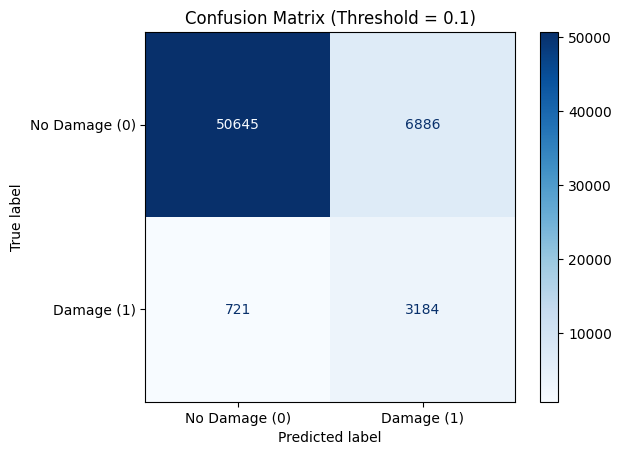

In [4]:
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Re-calculate predictions for the 0.25 threshold
optimal_threshold = 0.1
y_pred_optimal = (y_probs_local >= optimal_threshold).astype(int)

# 2. Calculate the new Balanced Accuracy
new_balanced_accuracy = balanced_accuracy_score(y_val_local, y_pred_optimal)
print(f"--- Performance at {optimal_threshold} Threshold ---")
print(f"Validation Balanced Accuracy : {new_balanced_accuracy:.4f}")

# 3. Display the Confusion Matrix to see the real-world impact
print("\nPlotting Confusion Matrix...")
ConfusionMatrixDisplay.from_predictions(
    y_val_local, 
    y_pred_optimal, 
    display_labels=['No Damage (0)', 'Damage (1)'],
    cmap='Blues'
)
plt.title(f"Confusion Matrix (Threshold = {optimal_threshold})")
plt.show()

# XG Boost

In [5]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


Calculated scale_pos_weight: 14.73
Training XGBoost model... (This is usually faster than Random Forest)

--- XGBoost Baseline Evaluation ---
              precision    recall  f1-score   support

           0       0.99      0.87      0.92     57531
           1       0.30      0.84      0.44      3905

    accuracy                           0.87     61436
   macro avg       0.64      0.85      0.68     61436
weighted avg       0.94      0.87      0.89     61436

ROC-AUC Score: 0.9318


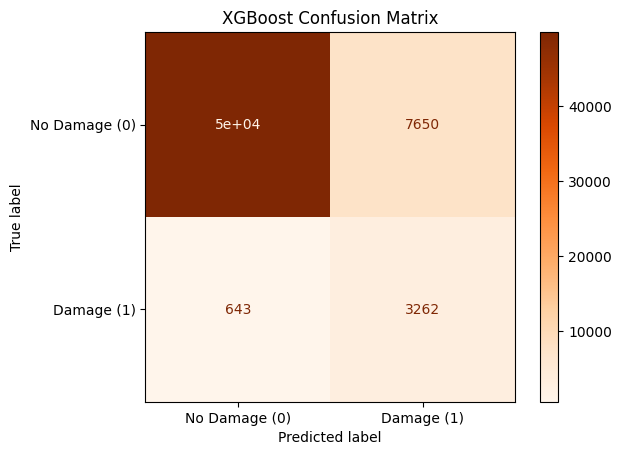

In [6]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Calculate the ideal 'scale_pos_weight'
# Formula: (Total Negative Class) / (Total Positive Class)
neg_class_count = (y_train_local == 0).sum()
pos_class_count = (y_train_local == 1).sum()
spw = neg_class_count / pos_class_count

print(f"Calculated scale_pos_weight: {spw:.2f}")

# 2. Initialize the XGBoost Classifier
# We set eval_metric to 'auc' because ROC-AUC is our best indicator of success here
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=spw,
    n_estimators=200,       # Number of gradient boosted trees
    max_depth=5,            # How deep the trees can grow (5-7 is usually a good start)
    learning_rate=0.1,      # Step size shrinkage to prevent overfitting
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

# 3. Train the model
print("Training XGBoost model... (This is usually faster than Random Forest)")
xgb_model.fit(X_train_local, y_train_local)

# 4. Make Predictions
# By default, this uses the standard 0.50 threshold
y_pred_xgb = xgb_model.predict(X_val_local)
y_probs_xgb = xgb_model.predict_proba(X_val_local)[:, 1]

# 5. Evaluate the Results
print("\n--- XGBoost Baseline Evaluation ---")
print(classification_report(y_val_local, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_val_local, y_probs_xgb):.4f}")

# 6. Plot the Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_val_local, 
    y_pred_xgb, 
    display_labels=['No Damage (0)', 'Damage (1)'],
    cmap='Oranges' # Using a different color to distinguish from the RF matrix
)
plt.title("XGBoost Confusion Matrix")
plt.show()

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score

# 1. Get probabilities once
y_probs_xgb = xgb_model.predict_proba(X_val_local)[:, 1]

# 2. Unified threshold range (covers both your previous lists)
thresholds = [0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

print("--- Combined Threshold Tuning Results ---")
print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall(1)':<10} | {'Recall(0)':<10} | {'F1':<10} | {'Bal Acc':<10}")
print("-" * 80)

# 3. Loop once
for t in thresholds:
    y_pred_custom = (y_probs_xgb >= t).astype(int)
    
    precision = precision_score(y_val_local, y_pred_custom, zero_division=0)
    recall_1 = recall_score(y_val_local, y_pred_custom, pos_label=1, zero_division=0)
    recall_0 = recall_score(y_val_local, y_pred_custom, pos_label=0, zero_division=0)
    f1 = f1_score(y_val_local, y_pred_custom, zero_division=0)
    bal_acc = balanced_accuracy_score(y_val_local, y_pred_custom)
    
    print(f"{t:<10.2f} | {precision:<10.4f} | {recall_1:<10.4f} | {recall_0:<10.4f} | {f1:<10.4f} | {bal_acc:<10.4f}")

--- Combined Threshold Tuning Results ---
Threshold  | Precision  | Recall(1)  | Recall(0)  | F1         | Bal Acc   
--------------------------------------------------------------------------------
0.30       | 0.1969     | 0.9173     | 0.7461     | 0.3243     | 0.8317    
0.40       | 0.2453     | 0.8786     | 0.8166     | 0.3836     | 0.8476    
0.45       | 0.2708     | 0.8556     | 0.8436     | 0.4114     | 0.8496    
0.50       | 0.2989     | 0.8353     | 0.8670     | 0.4403     | 0.8512    
0.55       | 0.3353     | 0.8074     | 0.8914     | 0.4739     | 0.8494    
0.60       | 0.3713     | 0.7723     | 0.9112     | 0.5015     | 0.8418    
0.65       | 0.4174     | 0.7360     | 0.9303     | 0.5327     | 0.8331    
0.70       | 0.4621     | 0.6909     | 0.9454     | 0.5538     | 0.8182    
0.75       | 0.5183     | 0.6471     | 0.9592     | 0.5756     | 0.8031    
0.80       | 0.5816     | 0.5956     | 0.9709     | 0.5886     | 0.7833    
0.85       | 0.6582     | 0.5311     | 0.

# Final Submission

In [8]:
import pandas as pd

# 1. Load the sample submission to get the correct formatting and IDs
# (Kaggle usually requires the exact IDs from the test set)
submission_df = pd.read_csv('sample_submission.csv')

# 2. Get the raw probabilities for the blind test set
print("Generating predictions on the test set...")
test_probs_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# 3. Apply your winning threshold (0.80)
optimal_xgb_threshold = 0.5
test_preds_final = (test_probs_xgb >= optimal_xgb_threshold).astype(int)

# 4. Assign the predictions to the target column in the submission file
# Make sure the column name matches exactly what Kaggle expects ('INDICATED_DAMAGE')
submission_df['INDICATED_DAMAGE'] = test_preds_final

# 5. Save the final file! 
# index=False prevents pandas from adding an extra column of row numbers
submission_filename = 'xgboost_final_submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Success! Saved to {submission_filename}.")
print("You are ready to upload this file to Kaggle!")

Generating predictions on the test set...


Success! Saved to xgboost_final_submission.csv.
You are ready to upload this file to Kaggle!


# XG Boost with Optuna

In [9]:
import sys
!{sys.executable} -m pip install optuna

Defaulting to user installation because normal site-packages is not writeable


In [10]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold



# # 1. Define the AI's search space
# def objective(trial):
#     # Optuna will test random combinations of these numbers
#     param = {
#         'scale_pos_weight': spw, # We keep our imbalanced weight!
#         'n_estimators': trial.suggest_int('n_estimators', 100, 400),
#         'max_depth': trial.suggest_int('max_depth', 3, 9),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
#         'eval_metric': 'auc',
#         'random_state': 42,
#         'n_jobs': -1 
#     }
    
#     # Create the model with the trial parameters
#     model = xgb.XGBClassifier(**param)
    
#     # Evaluate it using 3-Fold CV (We use 3 instead of 5 to make the search faster)
#     skf_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
#     # CRITICAL: We tell Optuna to hunt for the highest Balanced Accuracy
#     scores = cross_val_score(
#         model, 
#         X_train_processed, 
#         y_train, 
#         scoring='balanced_accuracy', 
#         cv=skf_tune, 
#         n_jobs=-1
#     )
    
#     return scores.mean()

# # 2. Run the Optimization!
# print("Unleashing Optuna! Testing 30 different tree architectures...")
# study = optuna.create_study(direction='maximize')
# # n_trials=30 will take a few minutes. If you want a better score, increase to 50 or 100!
# study.optimize(objective, n_trials=30)

# # 3. Print the winning results
# print("\n--- Optuna Tuning Complete ---")
# print(f"Best Balanced Accuracy Found: {study.best_value:.4f}")
# print("Optimal Parameters:")
# for key, value in study.best_params.items():
#     print(f"  {key}: {value}")

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score

# 1. Get probabilities once
y_probs_xgb = xgb_model.predict_proba(X_val_local)[:, 1]

# 2. Unified threshold range (covers both your previous lists)
thresholds = [0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

print("--- Combined Threshold Tuning Results ---")
print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall(1)':<10} | {'Recall(0)':<10} | {'F1':<10} | {'Bal Acc':<10}")
print("-" * 80)

# 3. Loop once
for t in thresholds:
    y_pred_custom = (y_probs_xgb >= t).astype(int)
    
    precision = precision_score(y_val_local, y_pred_custom, zero_division=0)
    recall_1 = recall_score(y_val_local, y_pred_custom, pos_label=1, zero_division=0)
    recall_0 = recall_score(y_val_local, y_pred_custom, pos_label=0, zero_division=0)
    f1 = f1_score(y_val_local, y_pred_custom, zero_division=0)
    bal_acc = balanced_accuracy_score(y_val_local, y_pred_custom)
    
    print(f"{t:<10.2f} | {precision:<10.4f} | {recall_1:<10.4f} | {recall_0:<10.4f} | {f1:<10.4f} | {bal_acc:<10.4f}")

--- Combined Threshold Tuning Results ---
Threshold  | Precision  | Recall(1)  | Recall(0)  | F1         | Bal Acc   
--------------------------------------------------------------------------------
0.30       | 0.1969     | 0.9173     | 0.7461     | 0.3243     | 0.8317    
0.40       | 0.2453     | 0.8786     | 0.8166     | 0.3836     | 0.8476    
0.45       | 0.2708     | 0.8556     | 0.8436     | 0.4114     | 0.8496    
0.50       | 0.2989     | 0.8353     | 0.8670     | 0.4403     | 0.8512    
0.55       | 0.3353     | 0.8074     | 0.8914     | 0.4739     | 0.8494    
0.60       | 0.3713     | 0.7723     | 0.9112     | 0.5015     | 0.8418    
0.65       | 0.4174     | 0.7360     | 0.9303     | 0.5327     | 0.8331    
0.70       | 0.4621     | 0.6909     | 0.9454     | 0.5538     | 0.8182    
0.75       | 0.5183     | 0.6471     | 0.9592     | 0.5756     | 0.8031    
0.80       | 0.5816     | 0.5956     | 0.9709     | 0.5886     | 0.7833    
0.85       | 0.6582     | 0.5311     | 0.

In [12]:
import sys
!{sys.executable} -m pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [13]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import balanced_accuracy_score
import pandas as pd

# 1. Initialize XGBoost (Blueprint ONLY - DO NOT FIT!)
print("Initializing model blueprints...")
best_xgb = xgb.XGBClassifier(
    scale_pos_weight=spw, 
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    n_estimators=398,
    max_depth=7,
    learning_rate=0.033718,
    subsample=0.639908,
    colsample_bytree=0.897904,
    min_child_weight=6
)

# 2. Initialize LightGBM (Blueprint ONLY)
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 3. Build the Ensemble (The Committee)
print("Building and Training the Ensemble... (This will train both models simultaneously)")
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', best_xgb), 
        ('lgb', lgb_model)
    ],
    voting='soft',
    n_jobs=-1 # This tells your CPU to train XGBoost and LightGBM at the exact same time!
)

# 4. Train the Ensemble (This does all the heavy lifting!)
ensemble_model.fit(X_train_processed, y_train)

# 5. Evaluate the Ensemble locally
print("\nEvaluating the Ensemble...")
y_pred_ensemble = ensemble_model.predict(X_val_local)
ensemble_bal_acc = balanced_accuracy_score(y_val_local, y_pred_ensemble)
print(f"--- Final Ensemble Local Validation ---")
print(f"Ensemble Balanced Accuracy: {ensemble_bal_acc:.4f}")

# ==========================================
# 6. GENERATE FINAL KAGGLE SUBMISSION
# ==========================================
print("\nGenerating final Kaggle predictions...")
submission_df = pd.read_csv('sample_submission.csv')

# The VotingClassifier automatically uses the 0.50 threshold on the averaged probabilities
test_preds_final = ensemble_model.predict(X_test_processed)

submission_df['INDICATED_DAMAGE'] = test_preds_final
submission_filename = 'ultimate_ensemble_submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Success! Saved to {submission_filename}. Go get that top score!")

Initializing model blueprints...
Building and Training the Ensemble... (This will train both models simultaneously)
[LightGBM] [Info] Number of positive: 19527, number of negative: 287651
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 9.973500 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 103191
[LightGBM] [Info] Number of data points in the train set: 307178, number of used features: 613
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

Evaluating the Ensemble...
--- Final Ensemble Local Validation ---
Ensemble Balanced Accuracy: 0.8740

Generating final Kaggle predictions...


/lusr/opt/python-3.13.1/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/lusr/opt/python-3.13.1/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Success! Saved to ultimate_ensemble_submission.csv. Go get that top score!
